# Public transport accessibility study in Malappuram, Kerala

#### This project analyzes the accessibility of public transport services in Malappuram district using GeoPandas and OSMnx. The study focuses on identifying unreserved areas by mapping bus stops from OpenStreetMap and overlaying them with population data from census shapefiles. By creating buffer zones around bus stops and performing spatial joins with population polygons,the project calculates coverage ratios and highlight regions where residents lack convenient access to public transport. The results provide actionable outputs for urban planners and transport authorities to improve connectivity and ensure equitable service distribution



### Collect Bus Stop Data





In [3]:
import osmnx as ox
# Query bus stops in Malappuram
bus_stops = ox.features_from_place(
    "Malappuram, Kerala, India",
    tags={"highway": "bus_stop"}
)

bus_stops.head()



geometry   highway shelter  bus  \
element id                                                             
node    550165648   POINT (76.07204 10.88929)  bus_stop      no  NaN   
        1465970791  POINT (76.09636 10.91675)  bus_stop     yes  yes   
        1465970792   POINT (76.09801 10.9211)  bus_stop     yes  yes   
        1466006847  POINT (76.09766 10.90444)  bus_stop     yes  yes   
        1466006853  POINT (76.08953 10.90261)  bus_stop     NaN  yes   

                              name public_transport departures_board  \
element id                                                             
node    550165648              NaN              NaN              NaN   
        1465970791  Athikarai Padi         platform              NaN   
        1465970792             NaN         platform              NaN   
        1466006847       Pookatiri         platform               no   
        1466006853      Palli Road         platform              NaN   

                   local_ref addr:city addr:postcode  ...  lit network  \
element id                                            ...                
node    550165648        NaN       NaN           NaN  ...  NaN     NaN   
        1465970791       NaN       NaN           NaN  ...  NaN     NaN   
        1465970792       NaN       NaN           NaN  ...  NaN     NaN   
        1466006847       NaN       NaN           NaN  ...  NaN     NaN   
        1466006853       NaN       NaN           NaN  ...  NaN     NaN   

                   operator:type addr:place main road alt_name level  \
element id                                                             
node    550165648            NaN        NaN       NaN      NaN   NaN   
        1465970791           NaN        NaN       NaN      NaN   NaN   
        1465970792           NaN        NaN       NaN      NaN   NaN   
        1466006847           NaN        NaN       NaN      NaN   NaN   
        1466006853           NaN        NaN       NaN      NaN   NaN   

                   description highway_1 opening_hours  
element id                                              
node    550165648          NaN       NaN           NaN  
        1465970791         NaN       NaN           NaN  
        1465970792         NaN       NaN           NaN  
        1466006847         NaN       NaN           NaN  
        1466006853         NaN       NaN           NaN  

[5 rows x 28 columns]

### save bus stop data 

In [5]:
bus_stops.to_file("data/malappuram_bus_stops.shp")

### Lets read Malappuram district boundary shapefile into geopandas dataframe

<Axes: >

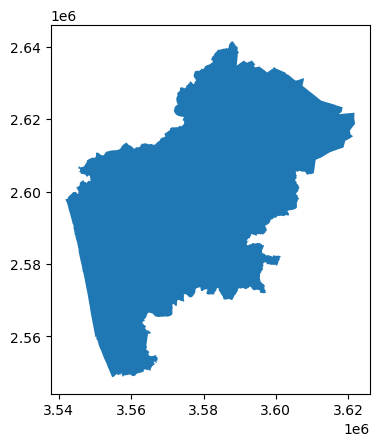

In [6]:
import geopandas as gpd
malappuram_boundary=gpd.read_file("data/malappuram_district.shp")
malappuram_boundary.plot()

###  Load Clipped Population Raster that I downloaded from world population data
#### We load the clipped population raster for Malappuram using Rasterio. This raster contains gridded population counts restricted to the district boundary.


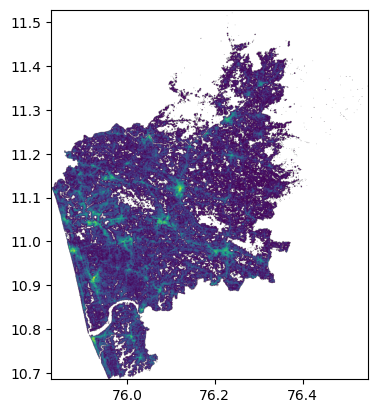

<Axes: >

In [7]:
import rasterio
from rasterio.plot import show

# Load the clipped raster
pop_raster = rasterio.open("data/malappuram_population.tif")

# Quick visualization
show(pop_raster)


### Lets inspect the raster properties

In [8]:
print("CRS:", pop_raster.crs)
print("Width:", pop_raster.width)
print("Height:", pop_raster.height)
print("Bounds:", pop_raster.bounds)
print("Resolution:", pop_raster.res)


CRS: EPSG:4326
Width: 868
Height: 1011
Bounds: BoundingBox(left=75.82583231003, bottom=10.685833626589982, right=76.54916564047, top=11.528333623219982)
Resolution: (0.000833333329999999, 0.00083333333)


### Lets load the reprojected raster layer to UTM 43N of Malappuram that I have done in QGIS

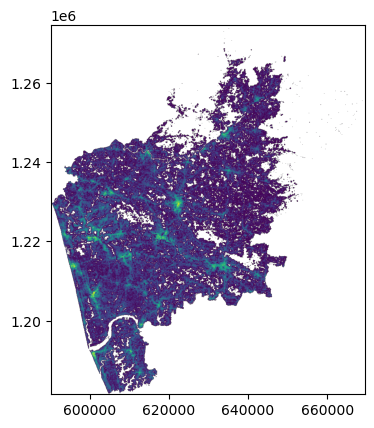

<Axes: >

In [10]:
pop_raster = rasterio.open("data/population_43N.tif")

# Quick visualization
show(pop_raster)

### Lets inspect properties again

In [11]:
print("CRS:", pop_raster.crs)
print("Width:", pop_raster.width)
print("Height:", pop_raster.height)
print("Bounds:", pop_raster.bounds)
print("Resolution:", pop_raster.res)


CRS: EPSG:32643
Width: 866
Height: 1020
Bounds: BoundingBox(left=590055.5088237991, bottom=1181341.1468490397, right=669450.6920702176, top=1274855.1040214957)
Resolution: (91.68035016907444, 91.68035016907444)


### Lets load bus stop data as geopandas dataframe check the crs of bus stops 

In [12]:
import geopandas as gpd
bus_stops=gpd.read_file("data/malappuram_bus_stops.shp")
bus_stops.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### Now convert the crs to UTM 43N and plot it

<Axes: >

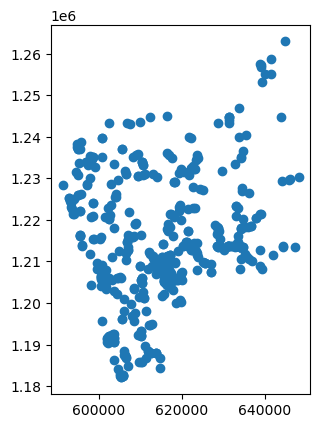

In [13]:
# Reproject bus stops to EPSG:32643
bus_stops = bus_stops.to_crs("EPSG:32643")

# Confirm CRS
bus_stops.crs

# Quick plot
bus_stops.plot()


### Lets create a buffer zone of 500m and assume it as walkable distance from bustop

In [25]:
# Example: 500 meter buffer
bus_buffers = bus_stops.copy()
bus_buffers["geometry"] = bus_buffers.buffer(500)
bus_buffers




,element,id,highway,shelter,bus,name,public_tra,departures,local_ref,addr_city,...,network,operator_t,addr_place,main road,alt_name,level,descriptio,highway_1,opening_ho,geometry
0,node,550165648,bus_stop,no,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((617663.941 1203945.219, 617661.534 1..."
1,node,1465970791,bus_stop,yes,yes,Athikarai Padi,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((620310.753 1206991.442, 620308.346 1..."
2,node,1465970792,bus_stop,yes,yes,NaN,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((620489.734 1207473.115, 620487.327 1..."
3,node,1466006847,bus_stop,yes,yes,Pookatiri,platform,no,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((620457.947 1205630.499, 620455.539 1..."
4,node,1466006853,bus_stop,NaN,yes,Palli Road,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((619569.593 1205425.177, 619567.186 1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474,node,13743607160,bus_stop,NaN,yes,Choonur,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Chunoor;Choonur;Chunur,NaN,NaN,NaN,NaN,"POLYGON ((615913.747 1214252.168, 615911.34 12..."
475,node,13782803807,bus_stop,yes,yes,Korippuram,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Koripuram,NaN,NaN,NaN,NaN,"POLYGON ((607106.796 1231069.971, 607104.389 1..."
476,node,13782803808,bus_stop,NaN,yes,Korippuram,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Koripuram,NaN,NaN,NaN,NaN,"POLYGON ((607097.66 1231071.943, 607095.252 12..."
477,node,13952041749,bus_stop,NaN,NaN,Pallappuram,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((602517.101 1190659.092, 602514.693 1..."


### Lets save the created buffer to data folder

In [4]:
bus_buffers.to_file("data/malappuram_busstop_buffers.shp")

### Use zonal stats to calculate sum of population values in each buffer and create a colimn pop_covered in bus_buffer dataframe

In [26]:
from rasterstats import zonal_stats

stats = zonal_stats(bus_buffers, "data/population_43N.tif", stats=["sum"])
bus_buffers["pop_covered"] = [s["sum"] for s in stats]


### Lets check the data

In [44]:
bus_buffers

,element,id,highway,shelter,bus,name,public_tra,departures,local_ref,addr_city,...,operator_t,addr_place,main road,alt_name,level,descriptio,highway_1,opening_ho,geometry,pop_covered
0,node,550165648,bus_stop,no,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((617663.941 1203945.219, 617661.534 1...",3757.634766
1,node,1465970791,bus_stop,yes,yes,Athikarai Padi,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((620310.753 1206991.442, 620308.346 1...",1183.453125
2,node,1465970792,bus_stop,yes,yes,NaN,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((620489.734 1207473.115, 620487.327 1...",1317.783813
3,node,1466006847,bus_stop,yes,yes,Pookatiri,platform,no,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((620457.947 1205630.499, 620455.539 1...",1727.683594
4,node,1466006853,bus_stop,NaN,yes,Palli Road,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((619569.593 1205425.177, 619567.186 1...",2041.827148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474,node,13743607160,bus_stop,NaN,yes,Choonur,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,Chunoor;Choonur;Chunur,NaN,NaN,NaN,NaN,"POLYGON ((615913.747 1214252.168, 615911.34 12...",856.382263
475,node,13782803807,bus_stop,yes,yes,Korippuram,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,Koripuram,NaN,NaN,NaN,NaN,"POLYGON ((607106.796 1231069.971, 607104.389 1...",1305.264404
476,node,13782803808,bus_stop,NaN,yes,Korippuram,platform,NaN,NaN,NaN,...,NaN,NaN,NaN,Koripuram,NaN,NaN,NaN,NaN,"POLYGON ((607097.66 1231071.943, 607095.252 12...",1308.195190
477,node,13952041749,bus_stop,NaN,NaN,Pallappuram,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((602517.101 1190659.092, 602514.693 1...",1387.934570


###  Clean Raster Data
#### We replace the NoData placeholder (-99999) with NaN so that invalid cells are ignored in calculations. This ensures only real population values are used.


In [39]:
import rasterio
import numpy as np

with rasterio.open("data/population_43N.tif") as src:
    arr = src.read(1)
    # Replace NoData (-99999) with NaN
    arr = np.where(arr == -99999, np.nan, arr)

    # Update metadata to record nodata
    meta = src.meta.copy()
    meta.update(nodata=np.nan)




###  Calculate Population in Buffers
#### We overlay bus stop buffers on the population raster and compute the sum of population values inside each buffer. This gives the number of people served by each bus stop.


In [40]:
from rasterstats import zonal_stats

stats = zonal_stats(
    bus_buffers,
    "data/population_43N.tif",
    stats=["sum"],
    nodata=-99999,   # explicitly ignore nodata
    geojson_out=False
)

bus_buffers["pop_covered"] = [s["sum"] if s["sum"] is not None else 0 for s in stats]



### Summarize Accessibility Coverage
#### We compare the total population covered by buffers with the district’s total population to calculate the percentage of residents who have bus stop access within 500m.


In [41]:
covered_pop = bus_buffers["pop_covered"].sum()

# Total population (ignoring nodata)
total_pop = np.nansum(arr)

coverage_ratio = covered_pop / total_pop * 100
print(f"Population coverage: {coverage_ratio:.2f}%")



Population coverage: 27.77%


### Lets merge bus stop buffers into one polygon

In [6]:

all_buffers = bus_buffers.union_all()


### Mask out the unserved population using rasterio

In [48]:
import rasterio.mask

with rasterio.open("data/population_43N.tif") as src:
    # Clip raster to areas outside buffers
    out_image, out_transform = rasterio.mask.mask(
        src, [all_buffers], invert=True, nodata=np.nan
    )
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform,
        "nodata": np.nan
    })


### Lets save the population of Malappuram which is unseved by bus stops under 500 meters

In [49]:

with rasterio.open("data/population_unserved.tif", "w", **out_meta) as dest:
    dest.write(out_image)


### Lets calculate amount of unserved population in Malappuram

In [2]:
import rasterio
import numpy as np

with rasterio.open("data/population_unserved.tif") as src:
    arr = src.read(1)
    # Ignore NoData values (-99999 or NaN)
    arr = np.where((arr == -99999) | np.isnan(arr), 0, arr)
    unserved_pop = np.sum(arr)

print(f"Unserved population: {unserved_pop:.0f}")


Unserved population: 2660096


#### Only 27.77% of Malappuram’s population lives within 500 m of a bus stop. The remaining population is underserved, highlighting areas where new bus stops could improve accessibility. 2660096 people are unserved by the bus stops under 500 meters